**Description**

This notebook is designed to process and prepare Balancer V2 Liquidity Bootstrapping Pool (LBP) data for machine learning analysis. Its main purposes are:

1. **Data Integration**: Merges multiple CSV files from the v2 directory into a single cohesive dataset using the `pool_id` as the common key.

2. **Data Cleaning**: Filters out invalid/inactive pools by:
   - Removing pools with missing launch dates or duration
   - Excluding pools that lasted less than 12 hours (zombie pools)
   - Identifying "dead pools" where price data is missing

3. **Feature Engineering**: Calculates derived metrics such as:
   - `weight_slope`: The rate of weight change over the LBP duration
   - Success indicators based on thresholds for price efficiency, bot volume, and activity entropy

4. **Target Variable Creation**: Generates multiple success metrics:
   - Individual success flags (price, bot volume, activity)
   - A combined `final_success` target variable that flags successful LBPs meeting all three criteria

5. **Exploratory Analysis**: Creates correlation heatmaps to identify which features are most predictive of LBP success.

6. **Output**: Saves the cleaned and finalized dataset as `FINAL_LBPs_BalancerV2.csv`, ready for machine learning modeling.

# Imports

In [1]:
import os
import pandas as pd
import numpy as np
from datetime import timedelta
import seaborn as sns
import matplotlib.pyplot as plt

# Merge CSVs

In [4]:
# Join all CSVs in ../media/v2 in relation to pool_id

df_final = pd.read_csv('../media/v2/LBPs_BalancerV2_general_metrics.csv')

for file in os.listdir('../media/v2'):
    if not file.endswith('.csv') or not file.startswith('LBPs_BalancerV2_'):
        continue
    df = pd.read_csv(os.path.join('../media/v2', file))
    if file != 'LBPs_BalancerV2_general_metrics.csv':
        print(f"Merging {file}...")
        df_final = pd.merge(df_final, df, on='pool_id', how='left')

df_final.drop(columns=['lbp_name','blockchain_x','blockchain_y','initial_price_usd','blockchain'], inplace=True)
df_final.info()

Merging LBPs_BalancerV2_activity_entropy.csv...
Merging LBPs_BalancerV2_Avg_Buy_Pressure_Price_Efficency_cleaned.csv...
Merging LBPs_BalancerV2_bot_volume_pct.csv...
Merging LBPs_BalancerV2_fdv+buy_pressure.csv...
Merging LBPs_BalancerV2_peak_activity.csv...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7179 entries, 0 to 7178
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pool_id             7179 non-null   object 
 1   launch_date         845 non-null    object 
 2   duration_h          845 non-null    float64
 3   start_weight_proj   845 non-null    float64
 4   end_weight_proj     845 non-null    float64
 5   total_swaps         7179 non-null   int64  
 6   unique_users        7179 non-null   int64  
 7   swaps_per_hour      7179 non-null   float64
 8   activity_entropy    1077 non-null   float64
 9   max_drawdown        1077 non-null   float64
 10  price_efficiency    210 non-null    float

In [5]:
df_final['weight_slope'] = np.where(
        df_final['duration_h'] > 0,
        (df_final['start_weight_proj'] - df_final['end_weight_proj']) / df_final['duration_h'],
        0
    )
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7179 entries, 0 to 7178
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pool_id             7179 non-null   object 
 1   launch_date         845 non-null    object 
 2   duration_h          845 non-null    float64
 3   start_weight_proj   845 non-null    float64
 4   end_weight_proj     845 non-null    float64
 5   total_swaps         7179 non-null   int64  
 6   unique_users        7179 non-null   int64  
 7   swaps_per_hour      7179 non-null   float64
 8   activity_entropy    1077 non-null   float64
 9   max_drawdown        1077 non-null   float64
 10  price_efficiency    210 non-null    float64
 11  bot_volume_pct      1077 non-null   float64
 12  initial_fdv_usd     763 non-null    float64
 13  buy_pressure_avg    4074 non-null   float64
 14  peak_activity_time  1077 non-null   float64
 15  weight_slope        7179 non-null   float64
dtypes: flo

In [6]:
def finalize_dataset_v2(df):
    print(f"Row Count Input: {len(df)}")
    
    # 1. CLEAN DATES & DURATION
    # Drop rows where we don't know the date
    df_clean = df.dropna(subset=['launch_date', 'duration_h', 'start_weight_proj']).copy()
    
    # 2. FILTER: REAL LBPs ONLY (Crucial Step)
    # We drop pools that lasted less than 12 hours. 
    # This removes the "Zero Duration" zombies causing the NaN slopes.
    df_clean = df_clean[df_clean['duration_h'] > 0]
    
    print(f"Row Count after Duration Filter (>12h): {len(df_clean)}")

    # 3. SMART IMPUTATION: End Weights (Flip Heuristic)
    mask_missing_end = df_clean['end_weight_proj'].isna()
    df_clean.loc[mask_missing_end, 'end_weight_proj'] = (1.0 - df_clean.loc[mask_missing_end, 'start_weight_proj']).clip(0.01, 0.99)
    
    # 4. RE-CALCULATE SLOPE (Safe Division)
    # Since duration > 12, we will never divide by zero here.
    df_clean['weight_slope'] = (df_clean['start_weight_proj'] - df_clean['end_weight_proj']) / df_clean['duration_h']

    # 5. FILL METRICS WITH 0
    cols_to_zero = [
        'initial_fdv_usd', 'buy_pressure_avg', 'max_drawdown', 
        'price_efficiency', 'bot_volume_pct', 'activity_entropy'
    ]
    # Fill only existing columns
    existing = [c for c in cols_to_zero if c in df_clean.columns]
    df_clean[existing] = df_clean[existing].fillna(0)

    # 6. GENERATE SUCCESS TARGETS
    df_clean['success_price'] = (df_clean['price_efficiency'] > 0.60).astype(int)
    df_clean['success_bot'] = (df_clean['bot_volume_pct'] < 0.50).astype(int)
    df_clean['success_activity'] = (df_clean['activity_entropy'] > 0.50).astype(int)
    
    df_clean['final_success'] = (
        (df_clean['success_price'] == 1) & 
        (df_clean['success_bot'] == 1) & 
        (df_clean['success_activity'] == 1)
    ).astype(int)
    
    return df_clean

# Usage
df_final_model_ready = finalize_dataset_v2(df_final)

print("\nFinal Dataset Overview:")
print(df_final_model_ready.info())
print("\nSuccess Distribution:")
print(df_final_model_ready['final_success'].value_counts())

Row Count Input: 7179
Row Count after Duration Filter (>12h): 426

Final Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
Index: 426 entries, 2 to 843
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pool_id             426 non-null    object 
 1   launch_date         426 non-null    object 
 2   duration_h          426 non-null    float64
 3   start_weight_proj   426 non-null    float64
 4   end_weight_proj     426 non-null    float64
 5   total_swaps         426 non-null    int64  
 6   unique_users        426 non-null    int64  
 7   swaps_per_hour      426 non-null    float64
 8   activity_entropy    426 non-null    float64
 9   max_drawdown        426 non-null    float64
 10  price_efficiency    426 non-null    float64
 11  bot_volume_pct      426 non-null    float64
 12  initial_fdv_usd     426 non-null    float64
 13  buy_pressure_avg    426 non-null    float64
 14  peak_activity_time  

In [7]:
# Assuming your filtered dataframe is named 'df_final_model_ready' (the 426 rows version)

# LOGIC: 
# In V1, we flagged rows where price data was missing.
# In V2, we filled missing price data with 0.
# Therefore: If price_efficiency is 0, it means it was a "Dead/Inactive" pool.

df_final_model_ready['is_dead_pool'] = (df_final_model_ready['price_efficiency'] == 0).astype(int)

# Verify the impact
print("Dead Pool Count in Final Set:")
print(df_final_model_ready['is_dead_pool'].value_counts())

# Check Success Balance again (Just to be sure)
print("\nFinal Success Balance:")
print(df_final_model_ready['final_success'].value_counts())

Dead Pool Count in Final Set:
is_dead_pool
1    304
0    122
Name: count, dtype: int64

Final Success Balance:
final_success
0    400
1     26
Name: count, dtype: int64


# Add new features

In [8]:
new_features_df = pd.read_csv('../media/v2/dev_V2_LBP_Pools_New_metrics.csv')
new_features_df = new_features_df[new_features_df['pool_id'].isin(df_final_model_ready['pool_id'])]
new_features_df = new_features_df[['pool_id','swap_fee_pct','initial_liquidity_usd','collateral_is_stable','is_weekend','hour_of_day']]
new_features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 426 entries, 675 to 1750
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pool_id                426 non-null    object 
 1   swap_fee_pct           426 non-null    float64
 2   initial_liquidity_usd  426 non-null    float64
 3   collateral_is_stable   426 non-null    int64  
 4   is_weekend             426 non-null    int64  
 5   hour_of_day            426 non-null    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 23.3+ KB


In [9]:
df_completed = pd.merge(df_final_model_ready, new_features_df, on='pool_id', how='left')

df_completed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pool_id                426 non-null    object 
 1   launch_date            426 non-null    object 
 2   duration_h             426 non-null    float64
 3   start_weight_proj      426 non-null    float64
 4   end_weight_proj        426 non-null    float64
 5   total_swaps            426 non-null    int64  
 6   unique_users           426 non-null    int64  
 7   swaps_per_hour         426 non-null    float64
 8   activity_entropy       426 non-null    float64
 9   max_drawdown           426 non-null    float64
 10  price_efficiency       426 non-null    float64
 11  bot_volume_pct         426 non-null    float64
 12  initial_fdv_usd        426 non-null    float64
 13  buy_pressure_avg       426 non-null    float64
 14  peak_activity_time     426 non-null    float64
 15  weight

# Analisys

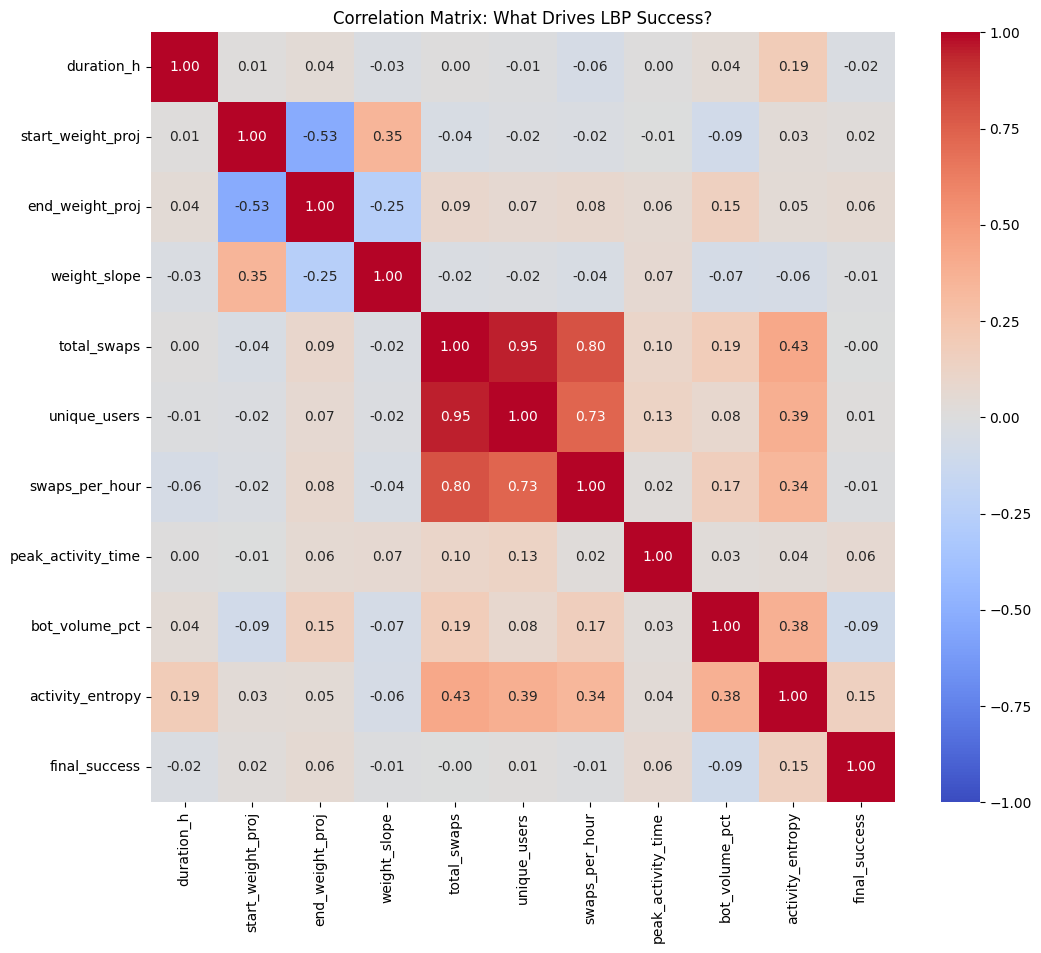

Correlations with 'final_success':
final_success         1.000000
activity_entropy      0.150372
peak_activity_time    0.064030
end_weight_proj       0.061385
start_weight_proj     0.015681
unique_users          0.013047
total_swaps          -0.004215
swaps_per_hour       -0.013135
weight_slope         -0.014625
duration_h           -0.024290
bot_volume_pct       -0.093805
Name: final_success, dtype: float64


In [20]:
def plot_correlation_heatmap(df):
    # 1. Select numeric columns only
    # We drop 'pool_id', 'launch_date', etc.
    cols_to_analyze = [
        'duration_h', 'start_weight_proj', 'end_weight_proj', 'weight_slope',
        'total_swaps', 'unique_users', 'swaps_per_hour', 'peak_activity_time',
        'initial_token_price', 'bot_volume_pct', 'activity_entropy',
        'final_success' # The Target
    ]
    
    # Filter for columns that actually exist in your DF
    existing_cols = [c for c in cols_to_analyze if c in df.columns]
    df_corr = df[existing_cols]

    # 2. Calculate Correlation
    corr_matrix = df_corr.corr()

    # 3. Plot Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix, 
        annot=True,     # Show numbers
        fmt=".2f",      # 2 decimal places
        cmap='coolwarm',# Red = Positive, Blue = Negative
        vmin=-1, vmax=1 # Fix scale from -1 to 1
    )
    plt.title('Correlation Matrix: What Drives LBP Success?')
    plt.show()
    
    # 4. Print numerical correlations with the Target
    print("Correlations with 'final_success':")
    print(corr_matrix['final_success'].sort_values(ascending=False))

# Usage
plot_correlation_heatmap(df_final_model_ready)

# Save final CSV

In [10]:
df_completed.to_csv('FINAL_LBPs_BalancerV2.csv', index=False)